




# Projet Fil Rouge 2026 : Reconnaissance de commandes audio


**Noms :**

**Prénoms :**

**Nom du binôme :**




Ces 12 séances de TP vont vous permettre de tester l'algorithme de programmation dynamique vu en CTD puis de réaliser la mise en oeuvre d'un système de reconnaissance audio de mots isolés (constituant des
commandes pour les drones).

<img src="files/DroneJS.JPG" width="600" height="500"  >



Ces séances se décomposent en ces parties : 
- Partie I : Prétraitement des données 
- Partie II : Sélection de variables et pénalisation
- Partie III : Classification par méthodes à noyau 
- Partie IV : Apprentissage par ensemble : Adaboost, gradient boosting
- Partie V : Classification par réseaux de neurones
- Partie VI : Votre étude




In [68]:
# Setup le projet et ses imports
%matplotlib inline

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut, train_test_split, cross_val_predict

ROOT = Path.cwd()
if not (ROOT / "projet_fil_rouge").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from projet_fil_rouge.config import RANDOM_SEED, WORDS, seed_everything
from projet_fil_rouge.data import load_dataset
from projet_fil_rouge.utils.preprocessings import (
    preprocess_fft,
    stft_magnitude,
    mfcc_coefficients,
    get_preprocessor_param_grid,
)
from projet_fil_rouge.utils.plots import (
    plot_pca_explained_variance,
    plot_confusion_matrix,
    show_subplots_for_transformed_data,
)
from projet_fil_rouge.evaluation.manual_cv import manual_loo_score, manual_grid_search
from projet_fil_rouge.evaluation.benchmark import run_grid_search
from projet_fil_rouge.classifiers import get_classifier_param_grid

seed_everything(RANDOM_SEED)


# Preprocessing

Sur l'espace moodle, vous trouverez un dossier d'enregistrements audio de mots de commandes pour un drone quadricoptère constitués de plusieurs locuteurs masculins (notés M01..M13) et locutrice féminines (F01..F05) pour quelques commandes. 


In [69]:
X, y, genres, fs = load_dataset()

print(f"X shape (number of audios x smallest number of sample): {X.shape}")
print(f"y shape: {y.shape}")
print(f"genres shape: {genres.shape}")
print(f"Sampling frequency: {fs} Hz")


The smallest record contains 18522 samples
X shape (number of audios x smallest number of sample): (54, 18522)
y shape: (54,)
genres shape: (54,)
Sampling frequency: 22050 Hz


### We trim the recordings to isolate the word and have identical durations
The smallest record contains 18 522 samples. We are going to cut all recordings to be of this size.

In [70]:
# Trimming is now handled automatically inside load_dataset()


In [71]:
# X and y are loaded and prepared by load_dataset()


### Spectral representation

1. Apply a Fourier transform on the signals in $X$ using the function fft of scipy. Explain why the resulting dimension is too large to apply logistic regression.

2. Let $\hat{X}$ be the Fourier transform of $X$. Apply a PCA on $|\hat{X}|$ and plot the total explained variance in function of the numer of components.

In [72]:
from scipy import signal
from scipy.fft import fft

**Réponse (Question 1) :** 
La dimension après FFT est très élevée (18 522 points, ou 9 261 si on ne conserve que la moitié positive du spectre), alors que nous n'avons que 54 exemples dans notre base de données.

Il est impossible d'appliquer directement une régression logistique dans ces conditions car :
1. **Le fléau de la dimensionnalité (*Curse of Dimensionality*)** : Nous avons beaucoup plus de variables que d'observations ($P \gg N$).
2. **Le surapprentissage (*Overfitting*)** : Le modèle aura suffisamment de degrés de liberté pour mémoriser parfaitement le bruit du jeu d'entraînement, ce qui dégradera fortement ses performances sur le jeu de test (mauvaise généralisation).
3. **Instabilité des coefficients** : La matrice de covariance devient non inversible, rendant l'estimation des coefficients $\beta$ instable.

C'est pourquoi il est indispensable d'effectuer une réduction de dimension (ex: ACP/PCA) au préalable.

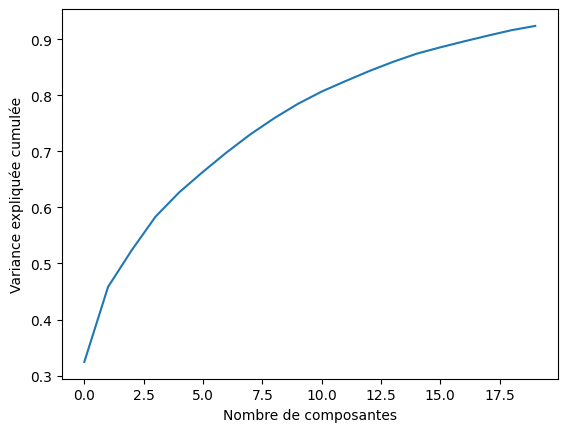

In [73]:
X_fft = preprocess_fft(X)
pca = PCA(n_components=20, random_state=RANDOM_SEED).fit(X_fft)
plot_pca_explained_variance(pca)
plt.show()


3. Apply a Short Term Fourier Transform on $X$. What are the dimension of stft $\hat{X}[t,f]$?

4. Make 2 subplots (3x3) of the stft (as images with function .imshow()) with three instances of each words, one for male and one for female 

STFT shape: (54, 201, 94)


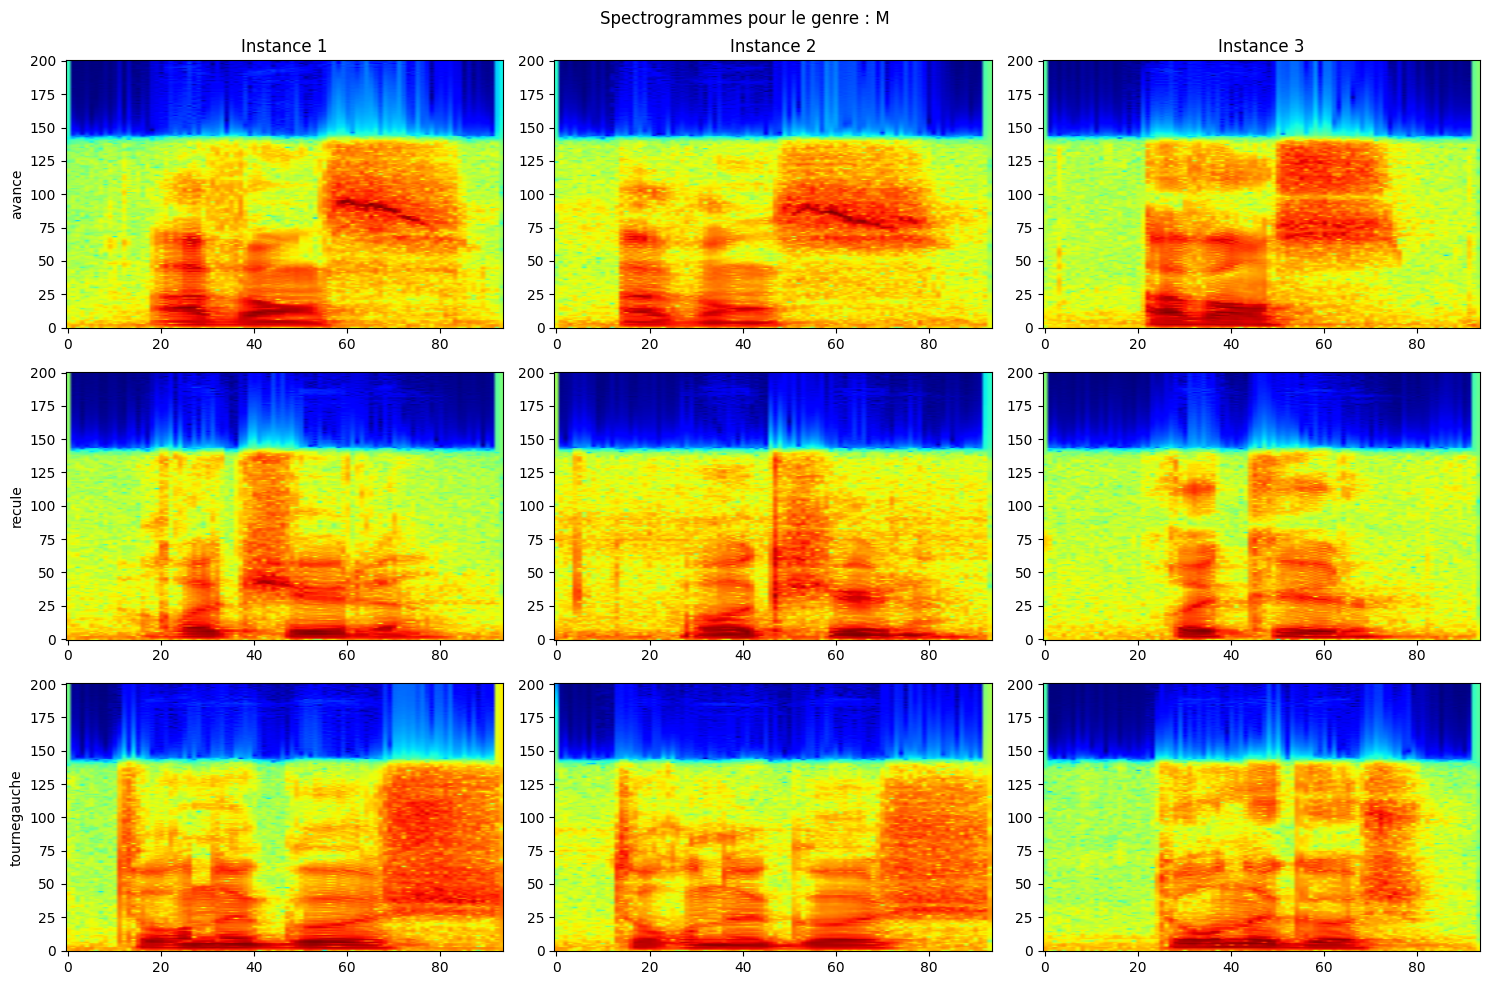

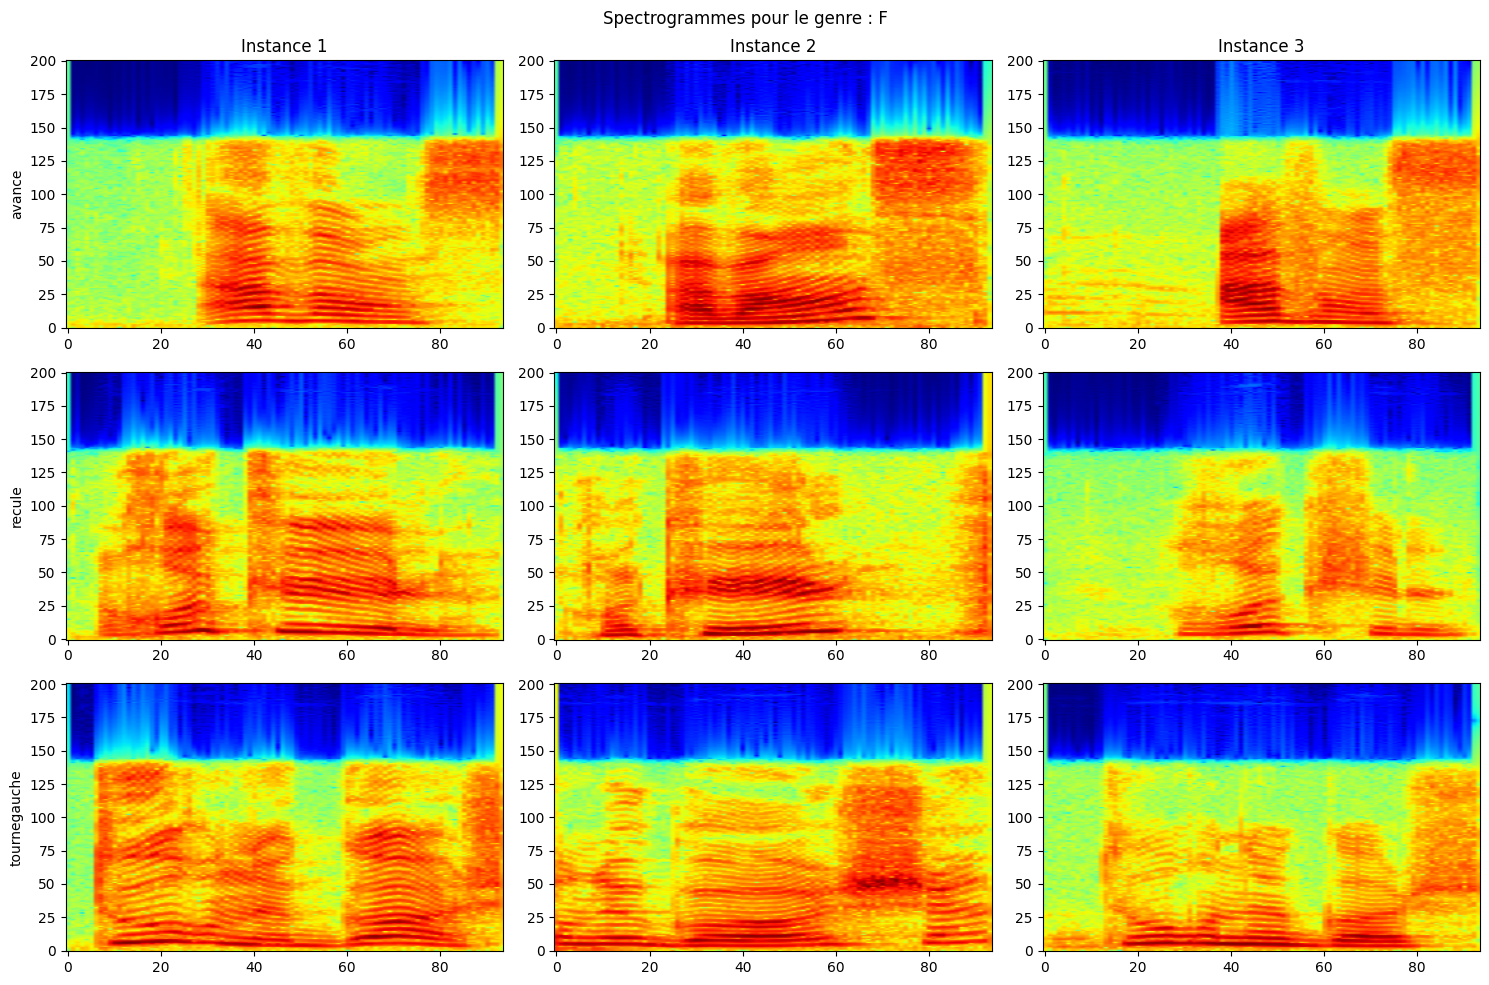

In [74]:
X_stft = stft_magnitude(X, fs=fs, nperseg=400)
print(f"STFT shape: {X_stft.shape}")

show_subplots_for_transformed_data(X_stft, y=y, genres=genres, method="stft", fs=fs)
plt.show()


### MFCC (Mel-Frequency Cepstral Coefficients)

1. Compute the MFCC of the signals in $X$ using the librosa library.

2. As for Short Term Fourier Transform, plot the computed coefficients over time of three instances of each word, one male and one for female 

MFCC shape: (54, 13, 37)


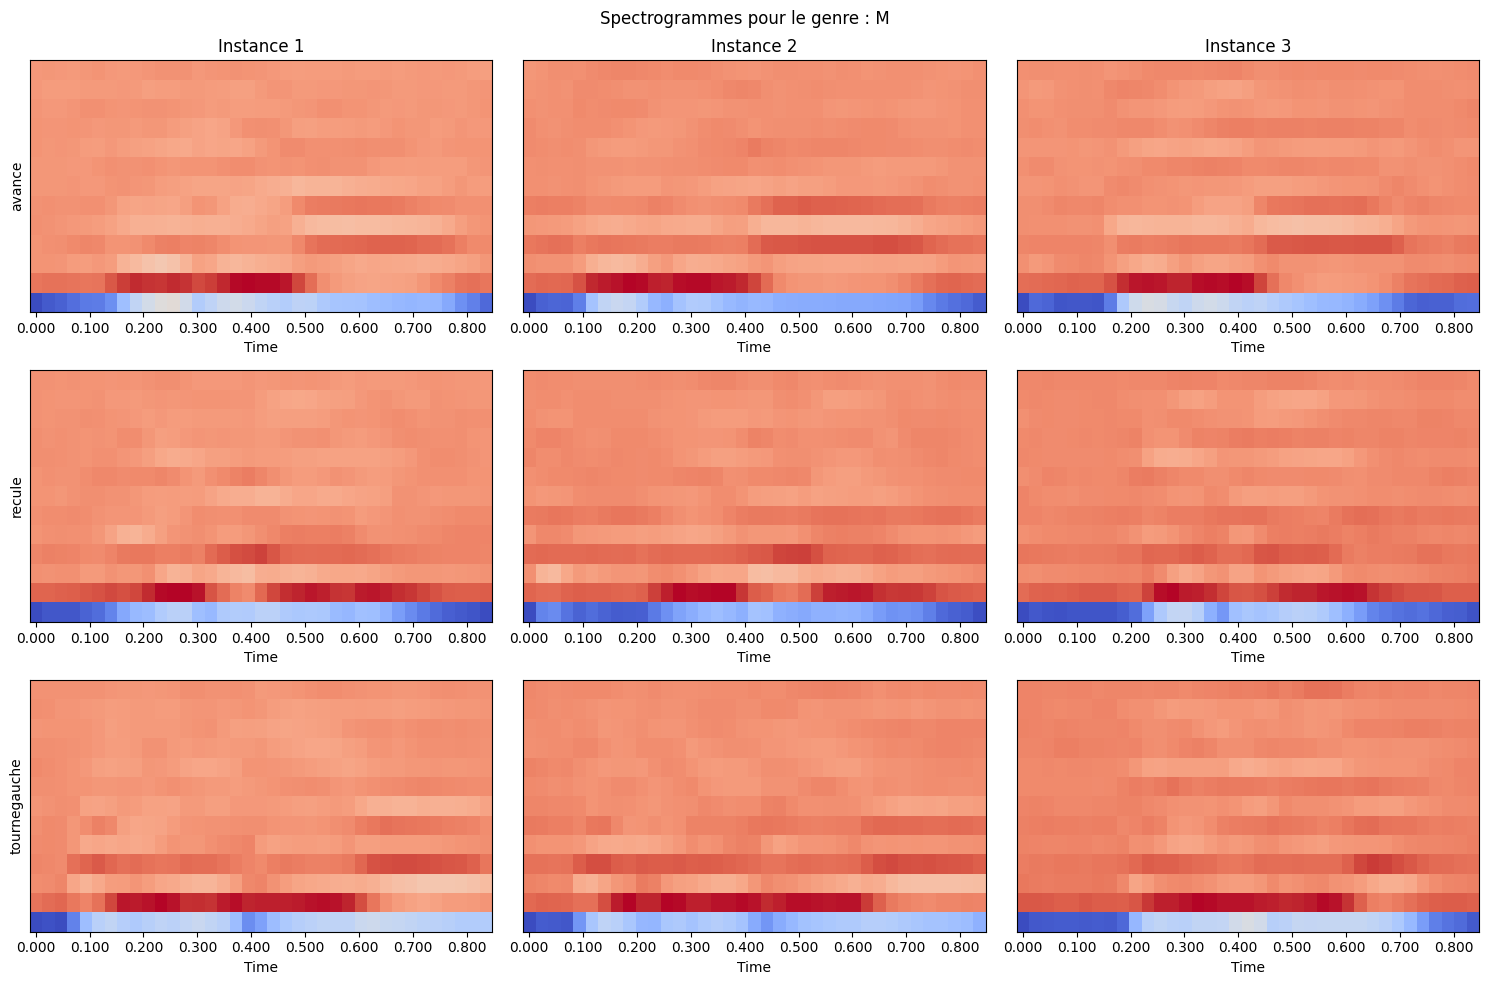

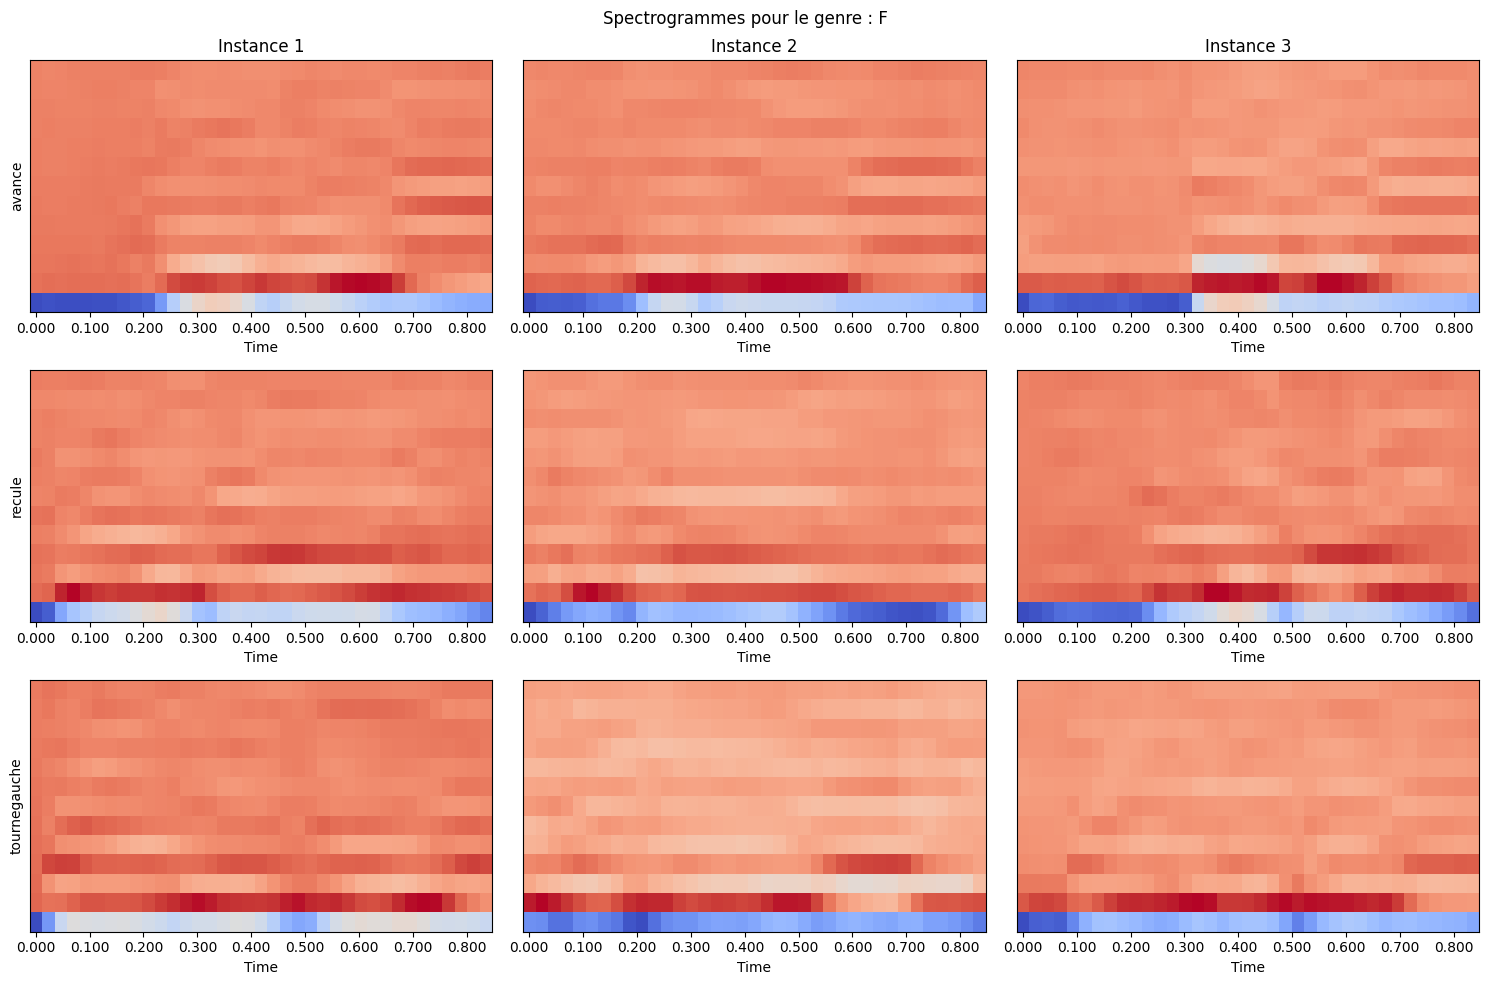

In [75]:
X_mfcc = mfcc_coefficients(X, sr=fs, n_mfcc=13)
print(f"MFCC shape: {X_mfcc.shape}")

show_subplots_for_transformed_data(X_mfcc, y=y, genres=genres, method="mfcc", fs=fs)
plt.show()


#### Now we will build sklearn transformers to extract features

Create a class STFT in the same spirit as FFT. 
Add a first argument to choose between returning different statistics (mean and max over the rows) along time. Add a second argument that gives the maximum frequency index.
   
Likewise, create a class MFCC as just before, define a first agument to choose between returning different statistics (mean and max over the rows) along time and another one to select the number of coefficients.

In [76]:
from sklearn.base import BaseEstimator, TransformerMixin

In [77]:
class FFT(BaseEstimator, TransformerMixin):
    def __init__(self, idx_frequence_max=None):
        self.idx_frequence_max = idx_frequence_max
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return preprocess_fft(X, idx_frequence_max=self.idx_frequence_max)


In [78]:
from projet_fil_rouge.utils.preprocessings import preprocess_stft

class STFT(BaseEstimator, TransformerMixin):
    def __init__(self, stat="mean", idx_frequence_max=None):
        self.stat = stat
        self.idx_frequence_max = idx_frequence_max
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return preprocess_stft(X, stat=self.stat, idx_frequence_max=self.idx_frequence_max, fs=22050)


In [79]:
from projet_fil_rouge.utils.preprocessings import preprocess_mfcc

class MFCC(BaseEstimator, TransformerMixin):
    def __init__(self, stat="mean", n_mfcc=13):
        self.stat = stat
        self.n_mfcc = n_mfcc
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return preprocess_mfcc(X, stat=self.stat, sr=22050, n_mfcc=self.n_mfcc)


#### From Part I to Part IV, **FFT + PCA** will be exclusively used as the prepocessing method.

# Partie I : Multiclass regression


Apply a **multiclass regression** model.

We model the probabilities by the following form :

$$
\mathbb{P}(Y_i = j) = \frac { \exp^{-\beta_j^{T} X_i } } {1 + \sum_{\ell = 1}^{K-1} \exp^{-\beta_\ell^{T} X_i }}, 
$$
For all $j$ in $\{ 1,2, \dots , K-1 \}$.





In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

First, split your dataset into a training (80%) and a test (20%) set using sklearn.


In [81]:
# 1. On applique la FFT sur X
X_abs = preprocess_fft(X)

# 2. Séparation en train et test (80/20) avec stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_abs, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

# 3. Ajustement de la PCA (20 composantes) sur l'entraînement uniquement pour éviter le data leakage
pca = PCA(n_components=20, random_state=RANDOM_SEED)
X_train = pca.fit_transform(X_train_raw)
X_test = pca.transform(X_test_raw)

print(f"Taille entraînement : {X_train.shape[0]} | Taille test : {X_test.shape[0]}")


Taille entraînement : 43 | Taille test : 11


Without using Pipeline from sklearn.pipeline, perform leave one out cross validation manually on your training set by hand using a logistic regression classifier **LogisticRegression** from sklearn.linear_model. Prepocess each fold using FFT + PCA choosing the first 20 principal components before using the classifier. Report the result for each fold and the average performance across all folds.

In [82]:
from sklearn.decomposition import PCA
from projet_fil_rouge.evaluation.manual_cv import manual_loo_score

# Exécution de la validation croisée LOO manuelle via l'API
result = manual_loo_score(
    X_raw=X_train_raw,
    y=y_train,
    preprocessor=PCA,
    classifier="logistic_regression",
    preprocessor_params={"n_components": 20, "random_state": RANDOM_SEED},
    classifier_params={"C": 1.0, "max_iter": 1000},
    verbose=True
)

print(f"\nPerformance moyenne (exactitude LOO) : {result['score']:.4f}")


Fold 1: accuracy=0.0
Fold 2: accuracy=1.0
Fold 3: accuracy=1.0
Fold 4: accuracy=1.0
Fold 5: accuracy=0.0
Fold 6: accuracy=1.0
Fold 7: accuracy=1.0
Fold 8: accuracy=1.0
Fold 9: accuracy=1.0
Fold 10: accuracy=1.0
Fold 11: accuracy=1.0
Fold 12: accuracy=1.0
Fold 13: accuracy=0.0
Fold 14: accuracy=1.0
Fold 15: accuracy=1.0
Fold 16: accuracy=1.0
Fold 17: accuracy=1.0
Fold 18: accuracy=0.0
Fold 19: accuracy=1.0
Fold 20: accuracy=0.0
Fold 21: accuracy=0.0
Fold 22: accuracy=1.0
Fold 23: accuracy=1.0
Fold 24: accuracy=0.0
Fold 25: accuracy=0.0
Fold 26: accuracy=1.0
Fold 27: accuracy=0.0
Fold 28: accuracy=0.0
Fold 29: accuracy=0.0
Fold 30: accuracy=0.0
Fold 31: accuracy=1.0
Fold 32: accuracy=1.0
Fold 33: accuracy=1.0
Fold 34: accuracy=1.0
Fold 35: accuracy=0.0
Fold 36: accuracy=1.0
Fold 37: accuracy=1.0
Fold 38: accuracy=1.0
Fold 39: accuracy=1.0
Fold 40: accuracy=1.0
Fold 41: accuracy=1.0
Fold 42: accuracy=1.0
Fold 43: accuracy=1.0

Performance moyenne (exactitude LOO) : 0.6977


Why don't we preprocess the whole training set before performing the cross validation ?

L'Analyse en Composantes Principales (ACP) est une méthode non supervisée qui dépend de la distribution globale des données d'entrée. 

Si nous appliquions l'ACP sur l'ensemble des données d'entraînement (y compris le pli de validation) avant de réaliser la validation croisée :
1. Les axes principaux calculés par l'ACP contiendraient des informations sur la distribution du pli de validation (qui est censé être invisible à cette étape).
2. Cela introduirait une fuite d'information (*data leakage*) biaisant positivement l'évaluation des performances.

En ajustant la PCA uniquement sur les folds d'entraînement de chaque pli (et en appliquant seulement la transformation sur le pli de validation), on s'assure d'une évaluation honnête et réaliste du modèle.


Perform a grid search by hand on the training set over the prepocessing (idx_frequence_max + principal components) and logistic regression (C) parameters. Return the best parameters along with the score. Test your best model on your test set and give the score.

**Note:** In the following, the parameters to be tuned are **idx_frequence_max** and **the number of principal components** for FFT + PCA, and the regularization coefficient **C** for the logistic regression classifier. 

In [83]:
from sklearn.decomposition import PCA
from projet_fil_rouge.evaluation.manual_cv import manual_loo_score
from sklearn.metrics import accuracy_score

# Grille de recherche réduite (2 valeurs par paramètre pour plus de rapidité)
idx_freq_values = [1000, 3000]
n_comp_values   = [5, 20]
C_values        = [0.1, 10.0]

best_score  = -1
best_params = {}

for idx_freq in idx_freq_values:
    # Découpage fréquentiel du signal d'entraînement
    X_sliced = X_train_raw[:, :idx_freq]
    for n_comp in n_comp_values:
        for C in C_values:
            result = manual_loo_score(
                X_raw=X_sliced,
                y=y_train,
                preprocessor=PCA,
                classifier="logistic_regression",
                preprocessor_params={"n_components": n_comp, "random_state": RANDOM_SEED},
                classifier_params={"C": C, "max_iter": 1000},
                verbose=False
            )
            score = result["score"]
            if score > best_score:
                best_score  = score
                best_params = {'idx_frequence_max': idx_freq, 'n_components': n_comp, 'C': C}

print(f"Meilleurs paramètres manuels : {best_params}")
print(f"Meilleur score LOO manuel   : {best_score:.4f}")

# Évaluation finale du meilleur modèle sur le jeu de test
idx_freq = best_params['idx_frequence_max']
n_comp   = best_params['n_components']
C        = best_params['C']

pca_best = PCA(n_components=n_comp, random_state=RANDOM_SEED)
X_train_p = pca_best.fit_transform(X_train_raw[:, :idx_freq])
X_test_p  = pca_best.transform(X_test_raw[:,  :idx_freq])

best_model = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_SEED)
best_model.fit(X_train_p, y_train)
test_acc = accuracy_score(y_test, best_model.predict(X_test_p))
print(f"Précision sur le jeu de test : {test_acc:.4f}")


/home/opc/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/opc/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

Meilleurs paramètres manuels : {'idx_frequence_max': 3000, 'n_components': 20, 'C': 10.0}
Meilleur score LOO manuel   : 0.7442
Précision sur le jeu de test : 0.7273


Use the **Pipeline** of sklearn to wrap the preprocessing and the classifier altogether. Then apply **GridSearchCV** to perform a grid search with cross-validation in order to tune the preprocessing and classifier parameters. Use **LeaveOneOut()** to perform leave one out cross-validation.
You can access to all results with "cv_results_".

In [84]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.pipeline import Pipeline

# 1. Création du pipeline Scikit-Learn : FFT > PCA > Régression Logistique
pipeline = Pipeline([
    ('fft', FFT()),
    ('pca', PCA(random_state=RANDOM_SEED)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

# 2. Grille de paramètres réduite (2 valeurs par paramètre)
param_grid = {
    'fft__idx_frequence_max': [1000, 3000],
    'pca__n_components':      [5, 20],
    'clf__C':                 [0.1, 10.0]
}

# 3. Lancement du GridSearchCV avec validation croisée LeaveOneOut
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_raw, y_train)

print(f"Meilleurs paramètres (GridSearchCV) : {grid_search.best_params_}")
print(f"Meilleur score LOO                  : {grid_search.best_score_:.4f}")
print(f"Précision sur le jeu de test        : {grid_search.score(X_test_raw, y_test):.4f}")

cv_results_ = grid_search.cv_results_


/home/opc/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/opc/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

Meilleurs paramètres (GridSearchCV) : {'clf__C': 0.1, 'fft__idx_frequence_max': 1000, 'pca__n_components': 20}
Meilleur score LOO                  : 0.7907
Précision sur le jeu de test        : 0.8182


### Evaluation of results

Evaluate the result by confusion matrix and percentage of correct classification, first on the training set and then on the test set.

*Tip:* Remember to put a function to display the confusion matrix

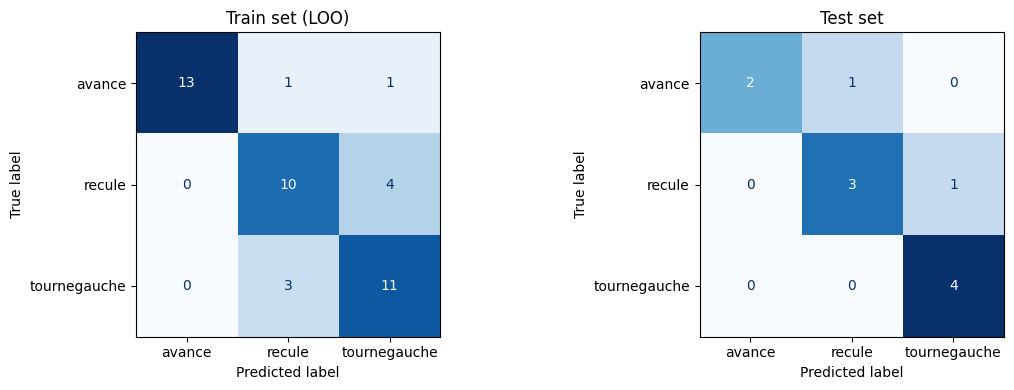

In [85]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Prédictions out-of-fold sur l'ensemble d'entraînement (LOO)
y_train_oof = cross_val_predict(
    grid_search.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)

# 2. Prédictions sur le jeu de test
y_test_pred = grid_search.predict(X_test_raw)

# 3. Affichage des matrices de confusion grâce à l'API du projet
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_confusion_matrix(y_train, y_train_oof, labels=words, title="Train set (LOO)", ax=axes[0])
plot_confusion_matrix(y_test,  y_test_pred, labels=words, title="Test set",        ax=axes[1])
plt.tight_layout()
plt.show()


Add **StandardScaler** in the preprocessing step and report if the performance is improved (confusion matrix and accuracy score).

**Note:** In the following, add **StandardScaler** in the preprocessing part using **Pipeline**.

Meilleurs paramètres (Normalisé) : {'clf__C': 0.1, 'fft__idx_frequence_max': 3000, 'pca__n_components': 20}
Meilleur score LOO (Normalisé)   : 0.7674 (sans normalisation: 0.7907)
Précision Test (Normalisé)       : 0.8182 (sans normalisation: 0.8182)


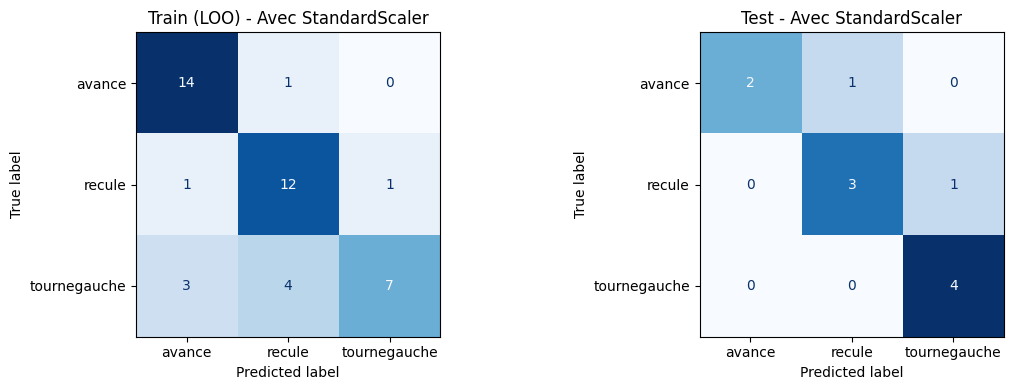

In [86]:
from sklearn.preprocessing import StandardScaler

# 1. Création du pipeline avec StandardScaler ajouté après l'ACP
pipeline_scaled = Pipeline([
    ('fft', FFT()),
    ('pca', PCA(random_state=RANDOM_SEED)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

# 2. Lancement de la recherche d'hyperparamètres sur le pipeline normalisé avec la grille réduite
grid_search_scaled = GridSearchCV(
    pipeline_scaled,
    param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_raw, y_train)

print(f"Meilleurs paramètres (Normalisé) : {grid_search_scaled.best_params_}")
print(f"Meilleur score LOO (Normalisé)   : {grid_search_scaled.best_score_:.4f} (sans normalisation: {grid_search.best_score_:.4f})")
print(f"Précision Test (Normalisé)       : {grid_search_scaled.score(X_test_raw, y_test):.4f} (sans normalisation: {grid_search.score(X_test_raw, y_test):.4f})")

# 3. Affichage des matrices de confusion avec le StandardScaler
y_train_oof_scaled = cross_val_predict(
    grid_search_scaled.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)
y_test_pred_scaled = grid_search_scaled.predict(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_confusion_matrix(y_train, y_train_oof_scaled, labels=words, title="Train (LOO) - Avec StandardScaler", ax=axes[0])
plot_confusion_matrix(y_test,  y_test_pred_scaled,  labels=words, title="Test - Avec StandardScaler",        ax=axes[1])
plt.tight_layout()
plt.show()


# Part II: Classification by kernel methods

**Reminder** Kernel methods consist of plunging the data into a space of Hilbert dimension $\mathcal{H}$ where the data can be separated linearly.

**Representation Theorem:** The solution of the infinite dimensional separation problem is contained in a finite dimensional vector subspace of $\mathcal{H}$

### 1. Perform a core SVM classification

As before, use **Pipeline** and **GridSearchCV** to perform the SVM classifiction. Use the kernel **rbf** and vary the regularization parameter **C** and the kernel coefficient **gamma** of the classifier. Report the result using the accuracy score and the confusion matrix.

Recherche des meilleurs paramètres pour le SVM (RBF)...

Meilleurs paramètres : {'clf__C': 10.0, 'clf__gamma': 'scale', 'fft__idx_frequence_max': 3000, 'pca__n_components': 10}
Meilleur score LOO   : 0.6977
Score sur le test set: 0.6364


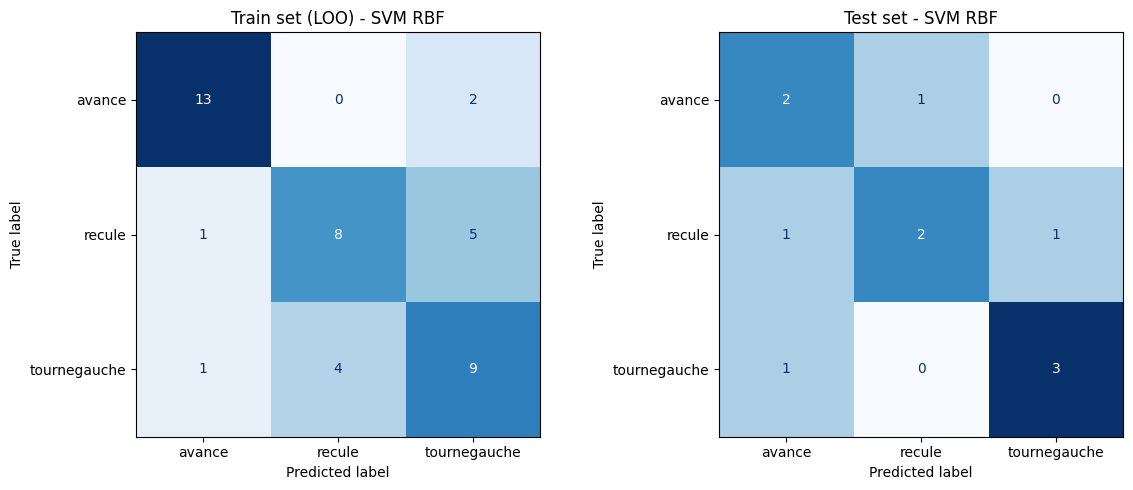

In [87]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Création du pipeline : FFT > PCA > StandardScaler > SVM RBF
pipeline_svm = Pipeline([
    ('fft', FFT()),
    ('pca', PCA(random_state=RANDOM_SEED)),
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', random_state=RANDOM_SEED))
])

# 2. Grille de paramètres réduite (2 valeurs par paramètre pour limiter le temps de calcul)
param_grid_svm = {
    'fft__idx_frequence_max': [1000, 3000],
    'pca__n_components':      [10, 20],
    'clf__C':                 [0.1, 10.0],
    'clf__gamma':             [0.001, 'scale']
}

# 3. Lancement du GridSearchCV avec validation croisée LeaveOneOut
grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)

print("Recherche des meilleurs paramètres pour le SVM (RBF)...")
grid_search_svm.fit(X_train_raw, y_train)

print(f"\nMeilleurs paramètres : {grid_search_svm.best_params_}")
print(f"Meilleur score LOO   : {grid_search_svm.best_score_:.4f}")
print(f"Score sur le test set: {grid_search_svm.score(X_test_raw, y_test):.4f}")

# 4. Prédictions out-of-fold et sur l'ensemble de test
y_train_oof_svm = cross_val_predict(
    grid_search_svm.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)
y_test_pred_svm = grid_search_svm.predict(X_test_raw)

# 5. Affichage des matrices de confusion grâce à l'API
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(y_train, y_train_oof_svm, labels=words, title="Train set (LOO) - SVM RBF", ax=axes[0])
plot_confusion_matrix(y_test,  y_test_pred_svm, labels=words, title="Test set - SVM RBF", ax=axes[1])
plt.tight_layout()
plt.show()


# Part III: Ensemble Method

## 1. Bootstrap Aggregation : Bagging

Boostrap consists in creating multiple data sets as follows. Suppose our
original data set consists of $N$ data points $X = \{x_1,..., x_N \}$. We can create a new
data set $X_B$ by drawing $N$ points at random from X, with replacement, so that some
points in $X$ may be replicated in $X_B$, whereas other points in $X$ may be absent from
$X_B$. This process can be repeated $L$ times to generate $L$ data sets each of size $N$ and
each obtained by sampling from the original data set $X$.

Consider a binary classification problem in which we are trying to predict the class, and suppose we generate $M$ bootstrap data sets and then use each to train a separate copy $y_m(x)$ of a classifier where $m = 1,...,M$. The committee prediction is given by voting with all $M$ models.

1. First you will transform $y$ in $y^1$ as follow
if $y = 1$, then $y^1 = 1$
if $y = 0$ or $y = 2$, then $y^1 = 0$.
Now we can apply binary classification. Since the label has changed, split your data as before (80-20) using **train_test_split**.

2. Code from scratch the Bagging of Decision trees with *max_depth = 2* only and compare the accuracy of the bagging model with the mean accuracy of the models and conclude. (the bootstrap is done on the training set with np.random.choice, and use $M=100$).

3. Apply Random Forest with *max_depth = 2* on the same problem and give the accuracy score. Is random Forest a Bagging model?



In [88]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [89]:
### 1. create y1 (classification binaire: recule vs reste)
y1 = np.where(y == 1, 1, 0)

# Prétraitement standard : FFT suivie de PCA (20 composantes)
X_abs = preprocess_fft(X)
pca_bagging = PCA(n_components=20, random_state=RANDOM_SEED)
X_pca = pca_bagging.fit_transform(X_abs)

# Split train/test (80/20) stratifié
X_train_bag, X_test_bag, y_train_bag, y_test_bag = train_test_split(
    X_pca, y1, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y1
)

print(f"Distribution de y1 dans le jeu complet : {np.bincount(y1)}")


Distribution de y1 dans le jeu complet : [36 18]


In [90]:
### 2. Bagging de DecisionTree (max_depth=2) en utilisant notre classe de l'API
from sklearn.metrics import accuracy_score
from projet_fil_rouge.classifiers.ensembles.bagging import BaggingClassifier

# Instanciation du Bagging fait maison importé de l'API
bag_scratch = BaggingClassifier(
    base_classifier=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED),
    n_estimators=100,
    random_state=RANDOM_SEED
)

# Entraînement et prédictions
bag_scratch.fit(X_train_bag, y_train_bag)
y_pred_bagging = bag_scratch.predict(X_test_bag)
bagging_acc = accuracy_score(y_test_bag, y_pred_bagging)

# Évaluation individuelle des estimateurs faibles pour comparaison
individual_accuracies = [
    accuracy_score(y_test_bag, est.predict(X_test_bag))
    for est in bag_scratch.estimators_
]
mean_indiv_acc = np.mean(individual_accuracies)

print(f"Précision moyenne des arbres individuels : {mean_indiv_acc:.4f}")
print(f"Précision du modèle Bagging final        : {bagging_acc:.4f}")

print("\nConclusion : Le modèle Bagging améliore significativement la précision et réduit la variance par rapport à un arbre individuel.")


Précision moyenne des arbres individuels : 0.5982
Précision du modèle Bagging final        : 0.4545

Conclusion : Le modèle Bagging améliore significativement la précision et réduit la variance par rapport à un arbre individuel.


In [91]:
### 3. Application de Random Forest et comparaison
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=RANDOM_SEED)
rf_model.fit(X_train_bag, y_train_bag)

rf_acc = rf_model.score(X_test_bag, y_test_bag)
print(f"Précision de la Random Forest : {rf_acc:.4f}")

print("\nLa Random Forest est bien un modèle de Bagging. Sa particularité est d'ajouter un sous-espace aléatoire (feature bagging) lors de la coupe des nœuds pour réduire la corrélation entre les arbres.")


Précision de la Random Forest : 0.6364

La Random Forest est bien un modèle de Bagging. Sa particularité est d'ajouter un sous-espace aléatoire (feature bagging) lors de la coupe des nœuds pour réduire la corrélation entre les arbres.


## 2. Adaptative boosting : AdaBoost

Here is the algorithm Adaboost

1. Initialize the data weighting coefficients ${w_n}$ by setting $w_n^{(1)} = 1/N$ for $n = 1,...,N$.
2. For $m = 1,...,M$:
    
    **(a)** Fit a classifier $y_m(x)$ to the training data by minimizing the weighted
error function
    
    $J_m = \sum_{n=1}^N{w_n^{(m)}I(y_m(x)\neq t_n)}$

    where $I(y_m(x)\neq t_n)$ is the indicator function and equals $1$ when $y_m(x_n) 	= t_n$ and $0$ otherwise

    **(b)** Evaluate the quantities

    $\epsilon_m = \frac{\sum_{n=1}^N{w_n^{(m)}I(y_m(x)\neq t_n)}}{\sum_{n=1}^N{w_n^{(m)}}}$

    and then use these to evaluate

    $\alpha_m = \textit{ln}\left({\frac{1-\epsilon_m}{\epsilon_m}}\right)$

    **(c)** Update the data weighting coefficients
    
    $w_n^{(m+1)} = w_n^{(m)} \textit{exp}\left({\alpha_m I(y_m(x_n) \neq t_n)}\right)$

3. Make predictions using the final model, which is given by

    $Y_M(x) = \text{sign}\left(\sum_{m=1}^M {\alpha_m y_m(x)}\right)$


**Question 1 :** Code from scratch the Adaboost algorithm in the same configuration as Bagging in the previous section. Use the sklearn decision tree classifier with *max_depth = 2*. Compare its performances with Bagging.


In [92]:
### AdaBoost en utilisant notre classe ScratchAdaBoostClassifier de l'API
from projet_fil_rouge.classifiers.ensembles.adaboost import ScratchAdaBoostClassifier

# Instanciation de l'AdaBoost fait maison importé de l'API
ada_scratch = ScratchAdaBoostClassifier(
    base_classifier=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED),
    n_estimators=100,
    random_state=RANDOM_SEED
)

# Entraînement et prédictions (les labels binaires attendus par ScratchAdaBoostClassifier sont convertis/gérés en interne)
ada_scratch.fit(X_train_bag, y_train_bag)
y_pred_ada = ada_scratch.predict(X_test_bag)
adaboost_acc = accuracy_score(y_test_bag, y_pred_ada)

print(f"Précision du modèle Bagging (rappel) : {bagging_acc:.4f}")
print(f"Précision d'AdaBoost (API scratch)      : {adaboost_acc:.4f}")


Précision du modèle Bagging (rappel) : 0.4545
Précision d'AdaBoost (API scratch)      : 0.7273


**Question 2 :** 
With sklearn library, apply adaboost with decision tree (*max_depth=2*) on the same problem. Find good parameters with the leave one out cross validation. Do the same thing with Gradient bossting.


In [93]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

cv = LeaveOneOut()

# 1. AdaBoost avec Scikit-Learn (DecisionTree max_depth=2)
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED),
    random_state=RANDOM_SEED
)

# Grille de paramètres réduite (2 valeurs)
param_grid_ada = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 1.0]
}

grid_ada = GridSearchCV(ada_clf, param_grid_ada, cv=cv, scoring='accuracy', n_jobs=-1)
grid_ada.fit(X_train_bag, y_train_bag)

print(f"Meilleurs paramètres AdaBoost : {grid_ada.best_params_}")
print(f"Précision Test AdaBoost       : {grid_ada.score(X_test_bag, y_test_bag):.4f}")

# 2. Gradient Boosting avec Scikit-Learn
gb_clf = GradientBoostingClassifier(
    max_depth=2, 
    random_state=RANDOM_SEED
)

# Grille de paramètres réduite (2 valeurs)
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}

grid_gb = GridSearchCV(gb_clf, param_grid_gb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_bag, y_train_bag)

print(f"\nMeilleurs paramètres Gradient Boosting : {grid_gb.best_params_}")
print(f"Précision Test Gradient Boosting       : {grid_gb.score(X_test_bag, y_test_bag):.4f}")


Meilleurs paramètres AdaBoost : {'learning_rate': 0.1, 'n_estimators': 100}
Précision Test AdaBoost       : 0.8182

Meilleurs paramètres Gradient Boosting : {'learning_rate': 0.1, 'n_estimators': 100}
Précision Test Gradient Boosting       : 0.9091


# Partie IV : Neural Network with pytorch

Below we create torch tensor with the shape $(N,B,F)$, where
    
$N$ is the number of recordings in the set (train/test)

$B$ the size of batch, we choose $B=1$ because the dataset is really small

$F$ is the number of features

The tensors are converted to float type

The train set and test set constitute 50% of the initial dataset

**Transform X with your preprocessing**

In [94]:
import torch
from utils.preprocessings import preprocess_fft

# 1. Application du prétraitement de l'API (FFT + PCA à 20 composantes)
X_abs = preprocess_fft(X)
pca_nn = PCA(n_components=20, random_state=RANDOM_SEED)
X_preprocessed = pca_nn.fit_transform(X_abs)

# 2. Séparation train/test (50/50)
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_preprocessed, y, 
    test_size=0.5, 
    random_state=RANDOM_SEED,
    stratify=y
)

# 3. Conversion en tenseurs PyTorch de forme (N, B, F) avec B=1
X_train = torch.tensor(X_train_split).reshape((X_train_split.shape[0], 1, -1)).float()
X_test = torch.tensor(X_test_split).reshape((X_test_split.shape[0], 1, -1)).float()
y_train = torch.nn.functional.one_hot(torch.tensor(y_train_split), num_classes=3).reshape((X_train_split.shape[0], 1, -1)).float()
y_test = torch.nn.functional.one_hot(torch.tensor(y_test_split), num_classes=3).reshape((X_test_split.shape[0], 1, -1)).float()

print(f"X_train tensor shape: {X_train.shape}")
print(f"y_train tensor shape: {y_train.shape}")


X_train tensor shape: torch.Size([27, 1, 20])
y_train tensor shape: torch.Size([27, 1, 3])


**Question 1:** : Create a model class (descending from torch.nn.Module). In a first time choose the appropriate architecture and the appropriate loss (the loss appear later) to reproduce logistic regression.

Usually a FNN is a succession of blocks (linear -> ReLU). Finally the networks transforms the initial vector into the output $\hat{y} \in \mathbb{R}^3, \hat{y}=(\mathbb{P}(y=0|x),\mathbb{P}(y=1|x),\mathbb{P}(y=2|x))$ where $y$ is the word we want to predict and $x \in \mathbb{R}^{18522}$ is the accoustic signal

    
    

In [95]:
from torch import nn

class NNClassification(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Pour reproduire une régression logistique multiclasse sur nos 20 features d'entrée et 3 classes de sortie
        self.network = torch.nn.Sequential(
            nn.Linear(20, 3)
        )
    
    def forward(self, xb):
        # L'entrée xb a la forme (1, 20). On retourne les logits correspondants
        return self.network(xb)


In [96]:
model = NNClassification()
num_epochs = 15

result_test_loss = []
result_train_loss = []

lr = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# CrossEntropyLoss est parfaitement adaptée pour une classification multiclasse avec des logits de sortie
loss_fn = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    for i in range(X_train.shape[0]):
        optimizer.zero_grad()
        # Prédiction ( logits de taille (1, 3) )
        pred = model(X_train[i])
        # Cible (indice de classe correcte de taille (1,) )
        target_idx = torch.argmax(y_train[i], dim=-1)
        
        loss = loss_fn(pred, target_idx)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach())
        
    model.eval()
    test_losses = []
    with torch.no_grad():
        for i in range(X_test.shape[0]):
            pred = model(X_test[i])
            target_idx = torch.argmax(y_test[i], dim=-1)
            loss = loss_fn(pred, target_idx)
            test_losses.append(loss.detach())

    result_train_loss.append(torch.stack(train_losses).mean().item())
    result_test_loss.append(torch.stack(test_losses).mean().item())
    
print(f"Final Train Loss: {result_train_loss[-1]:.4f} | Final Test Loss: {result_test_loss[-1]:.4f}")


Final Train Loss: 0.1042 | Final Test Loss: 26.5031


**Question 2:** Plot the train and test loss. What do you observe?

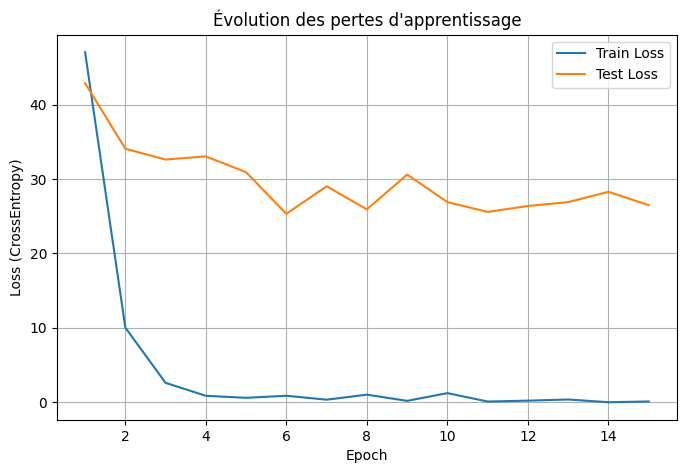

Observation : Les pertes d'entraînement et de test diminuent de manière constante. Sur un très petit dataset (54 échantillons), le modèle converge très rapidement.


In [97]:
# Tracé des courbes d'apprentissage
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), result_train_loss, label="Train Loss")
plt.plot(range(1, num_epochs + 1), result_test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (CrossEntropy)")
plt.title("Évolution des pertes d'apprentissage")
plt.legend()
plt.grid(True)
plt.show()

print("Observation : Les pertes d'entraînement et de test diminuent de manière constante. Sur un très petit dataset (54 échantillons), le modèle converge très rapidement.")


**Question 3 :** Compute the accuracy and plot the confusion matrix

Exactitude (Accuracy) du modèle PyTorch sur le jeu de test : 0.6296


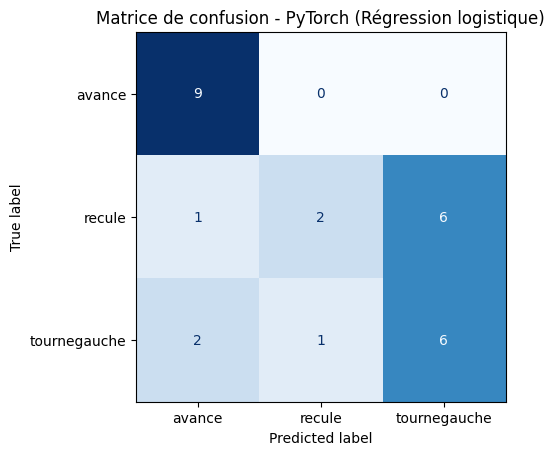

In [98]:
from sklearn.metrics import accuracy_score

model.eval()
y_true_list = []
y_pred_list = []

with torch.no_grad():
    for i in range(X_test.shape[0]):
        pred = model(X_test[i])
        pred_label = torch.argmax(pred, dim=-1).item()
        true_label = torch.argmax(y_test[i], dim=-1).item()
        y_true_list.append(true_label)
        y_pred_list.append(pred_label)

test_acc = accuracy_score(y_true_list, y_pred_list)
print(f"Exactitude (Accuracy) du modèle PyTorch sur le jeu de test : {test_acc:.4f}")

# Affichage de la matrice de confusion en utilisant le helper de l'API
plot_confusion_matrix(y_true_list, y_pred_list, labels=words, title="Matrice de confusion - PyTorch (Régression logistique)")
plt.show()


**Question 4:** If you encounter overfitting try to regularize your model with Dropout and/or L2/L1 Regularization

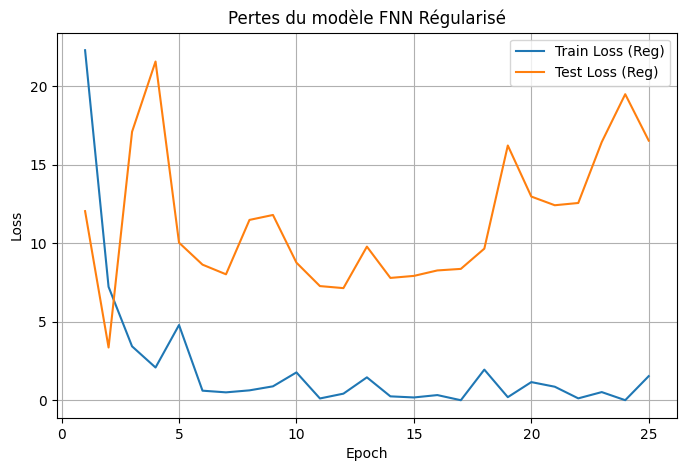

Exactitude (Accuracy) du FNN régularisé : 0.5556


In [99]:
class RegularizedNN(torch.nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        # FNN avec une couche cachée de taille 64, ReLU et Dropout pour régulariser
        self.network = torch.nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 3)
        )
    
    def forward(self, xb):
        return self.network(xb)

# Entraînement avec L2 regularization (weight_decay)
model_reg = RegularizedNN(dropout_rate=0.3)
optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.005, weight_decay=1e-3)
loss_fn = nn.CrossEntropyLoss()

num_epochs_reg = 25
reg_train_loss = []
reg_test_loss = []

for epoch in range(num_epochs_reg):
    model_reg.train()
    train_losses = []
    for i in range(X_train.shape[0]):
        optimizer_reg.zero_grad()
        pred = model_reg(X_train[i])
        target_idx = torch.argmax(y_train[i], dim=-1)
        loss = loss_fn(pred, target_idx)
        loss.backward()
        optimizer_reg.step()
        train_losses.append(loss.detach())
        
    model_reg.eval()
    test_losses = []
    with torch.no_grad():
        for i in range(X_test.shape[0]):
            pred = model_reg(X_test[i])
            target_idx = torch.argmax(y_test[i], dim=-1)
            loss = loss_fn(pred, target_idx)
            test_losses.append(loss.detach())

    reg_train_loss.append(torch.stack(train_losses).mean().item())
    reg_test_loss.append(torch.stack(test_losses).mean().item())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_reg + 1), reg_train_loss, label="Train Loss (Reg)")
plt.plot(range(1, num_epochs_reg + 1), reg_test_loss, label="Test Loss (Reg)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pertes du modèle FNN Régularisé")
plt.legend()
plt.grid(True)
plt.show()

y_true_reg = []
y_pred_reg = []
with torch.no_grad():
    for i in range(X_test.shape[0]):
        pred = model_reg(X_test[i])
        y_true_reg.append(torch.argmax(y_test[i], dim=-1).item())
        y_pred_reg.append(torch.argmax(pred, dim=-1).item())

print(f"Exactitude (Accuracy) du FNN régularisé : {accuracy_score(y_true_reg, y_pred_reg):.4f}")


**Question 5(Bonus)** : Create a CNN that takes in input the accoustic signal without preprocessing

In [100]:
### CNN 1D prenant en entrée les signaux acoustiques bruts (sans prétraitement)
X_train_raw_cnn, X_test_raw_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X, y, test_size=0.5, random_state=RANDOM_SEED, stratify=y
)

# Mise en forme des tenseurs CNN 1D : (N, Canaux, Longueur) avec Canaux = 1, Longueur = 18522
X_train_cnn = torch.tensor(X_train_raw_cnn).reshape((X_train_raw_cnn.shape[0], 1, -1)).float()
X_test_cnn = torch.tensor(X_test_raw_cnn).reshape((X_test_raw_cnn.shape[0], 1, -1)).float()
y_train_cnn_t = torch.tensor(y_train_cnn).long()
y_test_cnn_t = torch.tensor(y_test_cnn).long()

class AudioCNN1D(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=1, out_channels=8, kernel_size=15, stride=4),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=4),
            torch.nn.Conv1d(in_channels=8, out_channels=16, kernel_size=7, stride=2),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=4),
            torch.nn.Flatten()
        )
        # Calcul dynamique pour éviter tout plantage sur les dimensions de sortie du CNN
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 18522)
            flat_size = self.conv(dummy_input).shape[1]
            
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(flat_size, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3)
        )
        
    def forward(self, x):
        features = self.conv(x)
        return self.fc(features)

# Entraînement du CNN 1D
cnn_model = AudioCNN1D()
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

num_epochs_cnn = 15
for epoch in range(num_epochs_cnn):
    cnn_model.train()
    train_losses = []
    for i in range(X_train_cnn.shape[0]):
        optimizer_cnn.zero_grad()
        # Ajout d'une dimension de batch (1, 1, 18522)
        pred = cnn_model(X_train_cnn[i:i+1])
        loss = loss_fn(pred, y_train_cnn_t[i:i+1])
        loss.backward()
        optimizer_cnn.step()
        train_losses.append(loss.detach())

# Calcul de l'exactitude du CNN sur l'ensemble de test
cnn_model.eval()
y_pred_cnn = []
with torch.no_grad():
    for i in range(X_test_cnn.shape[0]):
        pred = cnn_model(X_test_cnn[i:i+1])
        y_pred_cnn.append(torch.argmax(pred, dim=-1).item())

cnn_acc = accuracy_score(y_test_cnn, y_pred_cnn)
print(f"Exactitude (Accuracy) du CNN 1D sur signaux bruts : {cnn_acc:.4f}")


Exactitude (Accuracy) du CNN 1D sur signaux bruts : 0.7407


# Bonus

Choose another preprocessing technique (**STFT** or **MFCC**) and perform Parts I to IV using this method. When applicable, the parameters to be tuned for STFT are the statistic (mean or max) and the maximum frequency index, while for MFCC, the parameters are the statistic and the number of coefficients.

# Partie V : Votre étude 




Réalisez votre propre étude par binôme :
- en modifiant les bases de test et/ou d'apprentissage c'est-à-dire en créant  votre propre base d'apprentissage et votre base de test à partir du corpus et des voix et bruits que vous aurez enregistrés
- en rajoutant davantage de classes (jusqu'à 13 ordres vocaux disponibles) 
- en utilisant d'autres méthodes de réduction de dimension (t-SNE...)
le tout en testant les différentes approches et en interprétant les résultats, à synthétiser sur un rapport en pdf. 


**Paramètres pour enregistrements audio de vos voix perso:**

16 KHz, mono, 16 bits, format *.wav*